# 1 — Prise en main

Ce notebook fait le tour de ce que le radar sait faire à partir de l'[open data
de l'Assemblée nationale](https://data.assemblee-nationale.fr) : qui vote avec
qui, quels groupes se fissurent, quels sujets montent, qui dépose quels
amendements. C'est la visite guidée, pas une enquête.

Les trois notebooks suivants forment une suite. Chacun montre qu'une réponse
apparemment solide reposait sur un **choix invisible**, et ce que ça change :

| | Le choix invisible | Ce qu'il change |
|---|---|---|
| `02` | la **population** de scrutins retenue | l'accord LFI↔SOC passe de 79 % à 63 % |
| `03` | la **relation** que l'on mesure | LFI et ECOS votent à 88 % et ne cosignent presque jamais |
| `04` | la **méthode** elle-même | ce qu'on a le droit d'affirmer |

Chacun est écrit en hypothèse → méthode → résultat → contre-épreuve, et
documente les biais rencontrés plutôt que les seules conclusions.

**Avant de lancer ce notebook**, construisez les tables :

```bash
uv run radar update --amendements
```

Les chiffres ci-dessous sont recalculés depuis le dépouillement nominatif de
chaque scrutin. Aucune interprétation politique n'est produite : le radar
signale des écarts, la lecture reste au lecteur.

In [1]:
import polars as pl
import matplotlib.pyplot as plt

from radar import analyze, alerts, topics, viz
from radar.parse import load

viz.set_theme("clair")          # "sombre" pour la version fond noir
pl.Config.set_tbl_rows(15)
pl.Config.set_fmt_str_lengths(60)

polars.config.Config

## 1. Ce qu'on a sous la main

Six tables, construites une fois pour toutes en Parquet.

In [2]:
for nom in ("deputes", "scrutins", "votes", "positions_groupe", "amendements"):
    try:
        df = load(nom)
        print(f"{nom:18s} {df.height:>9,} lignes")
    except FileNotFoundError:
        print(f"{nom:18s}   absente — lancez `uv run radar update --amendements`")

scrutins = load("scrutins")
print(f"\nScrutins du {scrutins['date'].min()} au {scrutins['date'].max()}")

deputes                  648 lignes
scrutins               8,434 lignes
votes              1,270,476 lignes
positions_groupe      91,996 lignes


amendements          123,224 lignes

Scrutins du 2024-10-08 au 2026-07-21


In [3]:
load("deputes").group_by("groupe").len().sort("len", descending=True)

groupe,len
str,u32
"""RN""",129
"""EPR""",116
"""LFI-NFP""",72
"""SOC""",70
"""DR""",64
"""HOR""",44
"""DEM""",42
"""ECOS""",38
"""LIOT""",25


## 2. Le cube de votes

Toutes les analyses partent de la même structure : la matrice
(députés × scrutins) des positions, doublée d'une matrice d'éligibilité qui dit
quels députés siégeaient à la date de chaque scrutin. Sans cette seconde
matrice, un député arrivé en cours de législature passerait pour un absentéiste.

In [4]:
cube = analyze.build_cube()          # députés en exercice, tous scrutins
print(f"{cube.n_deputes} députés × {cube.n_scrutins} scrutins")
print(f"votes exprimés : {cube.exprime.sum():,}")
print(f"couples (député, scrutin) où le député siégeait : {cube.eligible.sum():,}")

577 députés × 8434 scrutins
votes exprimés : 1,197,631
couples (député, scrutin) où le député siégeait : 4,842,932


## 3. « Quels députés votent le plus souvent ensemble ? »

L'accord entre deux députés est calculé sur les seuls scrutins où **les deux**
se sont prononcés : un absent n'est ni d'accord ni en désaccord. Les paires qui
partagent moins de trente scrutins sont écartées, sinon on obtiendrait des
« 100 % d'accord » sur trois votes.

### 3.1 Vue d'ensemble : groupe par groupe

Douze groupes, donc douze couleurs ? Non. Le rouge de LFI et celui de GDR sont
séparés par un ΔE de 5,4 — en dessous du plancher de 15, ils sont confondus même
en vision normale. Ici la couleur porte une **grandeur** sur une rampe unique, et
l'identité est portée par les axes.

findfont: Failed to find font weight semibold, now using 700.


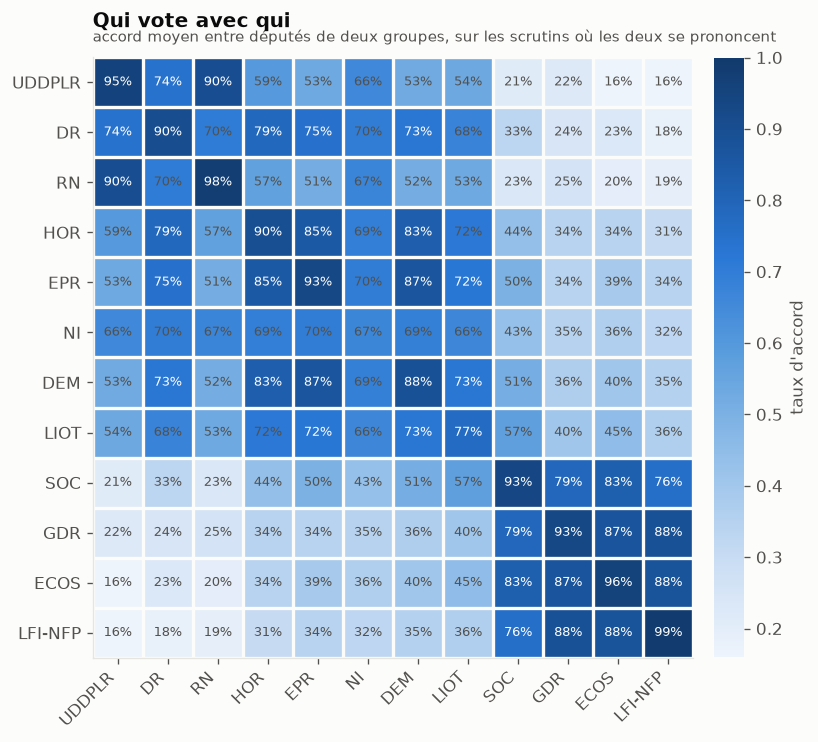

In [5]:
accords = analyze.accord_entre_groupes(cube)
viz.heatmap_groupes(accords)
plt.show()

La lecture se fait par blocs : le carré des groupes de gauche en haut à gauche,
le bloc de droite ailleurs, et la diagonale — toujours la plus foncée — donne la
cohésion interne de chaque groupe.

### 3.2 Cohésion interne des groupes

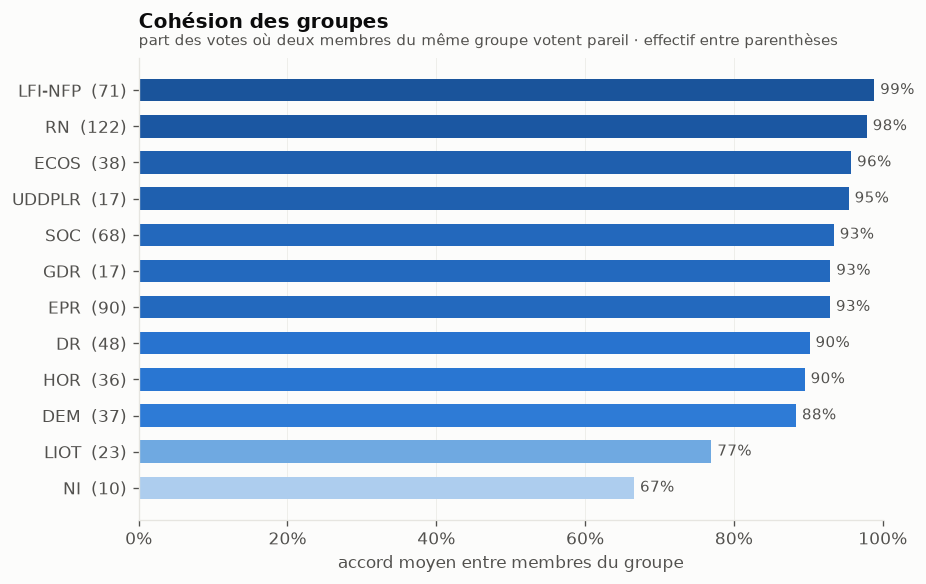

groupe,cohesion,effectif
str,f64,u32
"""LFI-NFP""",0.988644,71
"""RN""",0.978637,122
"""ECOS""",0.957607,38
"""UDDPLR""",0.954356,17
"""SOC""",0.934361,68
"""GDR""",0.92972,17
"""EPR""",0.929236,90
"""DR""",0.901745,48
"""HOR""",0.895226,36


In [6]:
cohesion = analyze.cohesion_groupes(cube)
viz.barres_cohesion(cohesion)
plt.show()
cohesion

Les non-inscrits ferment la marche, ce qui est mécanique : ce n'est pas un
groupe mais un résidu. LIOT, groupe-charnière revendiqué, est nettement moins
homogène que les autres — cette fois c'est une information politique.

### 3.3 Zoom sur un député

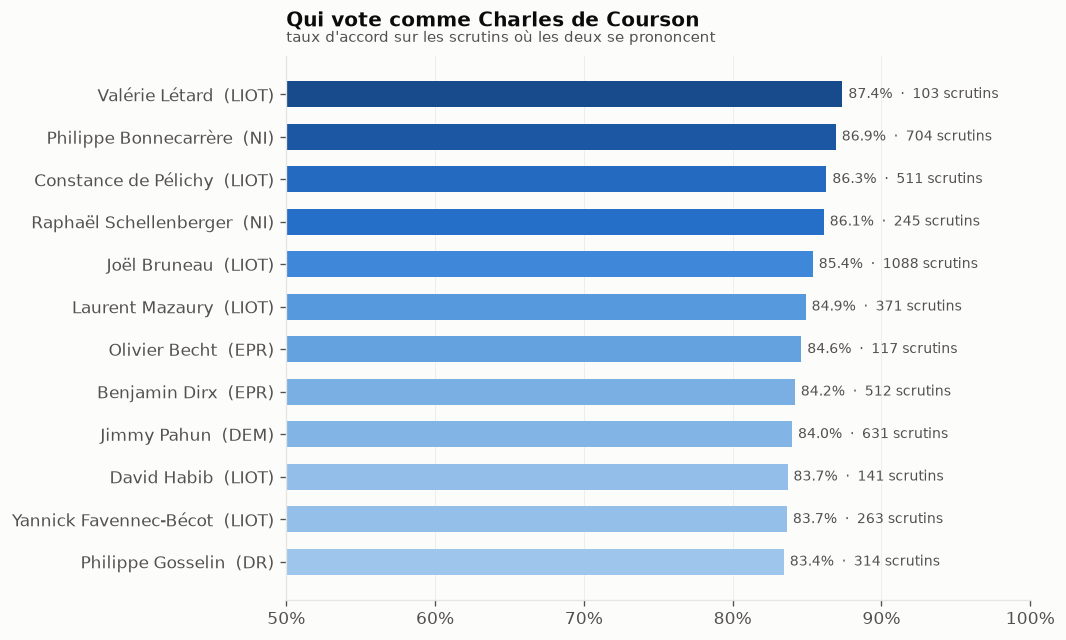

In [7]:
nom = "Charles de Courson"

proches = analyze.plus_proches(cube, nom, k=12)
viz.profil_depute(cube, proches, nom)
plt.show()

In [8]:
# Et hors de son propre groupe — souvent plus révélateur
analyze.plus_proches(cube, nom, k=10, hors_groupe=True)

depute,groupe,accord,scrutins_communs
str,str,f64,i64
"""Philippe Bonnecarrère""","""NI""",0.869318,704
"""Raphaël Schellenberger""","""NI""",0.861224,245
"""Olivier Becht""","""EPR""",0.846154,117
"""Benjamin Dirx""","""EPR""",0.841797,512
"""Jimmy Pahun""","""DEM""",0.839937,631
"""Philippe Gosselin""","""DR""",0.834395,314
"""Jean-Louis Thiériot""","""DR""",0.827586,203
"""Danielle Brulebois""","""EPR""",0.824341,797
"""Bruno Fuchs""","""DEM""",0.823045,243


In [9]:
# À l'opposé : ceux dont il ne partage presque jamais le vote
analyze.plus_proches(cube, nom, k=8, inverse=True)

depute,groupe,accord,scrutins_communs
str,str,f64,i64
"""Jean-Philippe Nilor""","""LFI-NFP""",0.241546,207
"""Sébastien Delogu""","""LFI-NFP""",0.248408,314
"""Ugo Bernalicis""","""LFI-NFP""",0.256798,331
"""Paul Vannier""","""LFI-NFP""",0.261667,600
"""Jean-Victor Castor""","""GDR""",0.270161,248
"""Davy Rimane""","""GDR""",0.272727,88
"""Shéhérazade Bentorki""","""LFI-NFP""",0.27451,102
"""Jean-Hugues Ratenon""","""LFI-NFP""",0.27551,490


### 3.4 Alliances qui traversent les groupes

Deux députés du même groupe qui votent pareil, ce n'est pas une information.
Deux députés de groupes différents à 99 % d'accord, si.

In [10]:
analyze.paires_remarquables(cube, k=15)

depute_a,groupe_a,depute_b,groupe_b,accord,scrutins_communs
str,str,str,str,f64,i64
"""Christine Le Nabour""","""HOR""","""Danièle Carteron""","""EPR""",0.995763,236
"""Christine Loir""","""RN""","""Sandra Delannoy""","""NI""",0.994539,1465
"""Emmanuel Fouquart""","""RN""","""Sandra Delannoy""","""NI""",0.991991,874
"""Brigitte Liso""","""EPR""","""Sabine Gervais""","""DEM""",0.991758,364
"""Marine Le Pen""","""RN""","""Sandra Delannoy""","""NI""",0.991597,476
"""Jorys Bovet""","""RN""","""Sandra Delannoy""","""NI""",0.990955,995
"""Christine Le Nabour""","""HOR""","""Marie-Philippe Lubet""","""EPR""",0.990826,109
"""Frédéric Valletoux""","""HOR""","""Sabine Gervais""","""DEM""",0.990712,323
"""Romain Tonussi""","""RN""","""Sandra Delannoy""","""NI""",0.990665,857


## 4. La carte des votes

On projette les députés en deux dimensions à partir de leurs votes. Deux députés
proches sur la carte votent de la même façon. Les axes n'ont pas de sens
politique intrinsèque : seul compte le positionnement relatif.

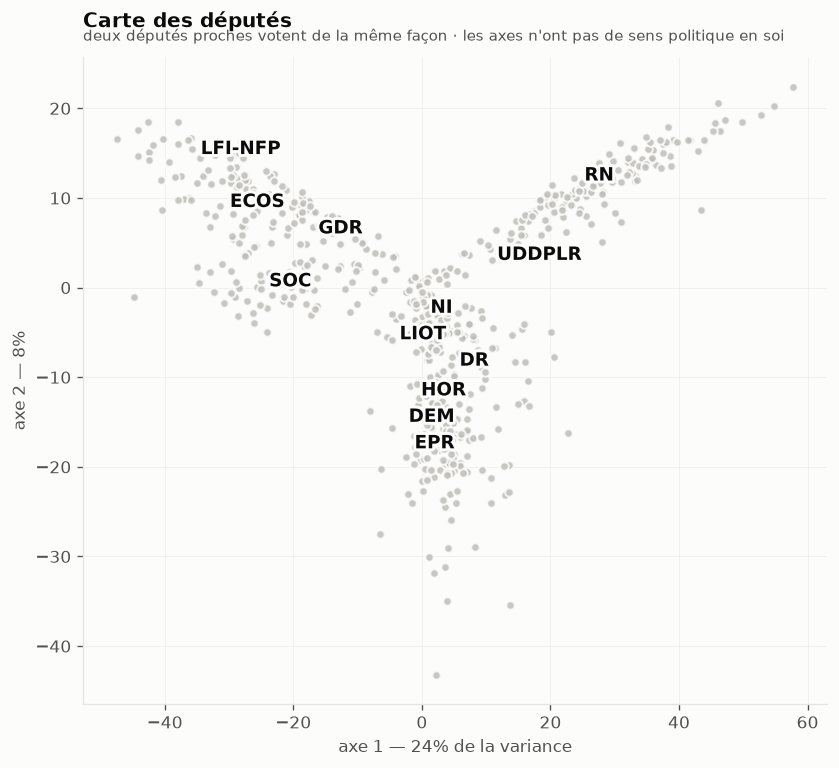

In [11]:
carte = analyze.carte_politique(cube, methode="pca")
viz.carte_apercu(carte)
plt.show()

Les points sont volontairement neutres : c'est le nom du groupe, posé au
barycentre de ses députés, qui porte l'identité.

Pour voir où se situe chaque groupe sans empiler douze teintes, on répète la
même carte en mettant un seul groupe en avant à chaque fois — la réponse
prescrite dès qu'un nuage de points dépasse trois classes.

findfont: Failed to find font weight semibold, now using 700.


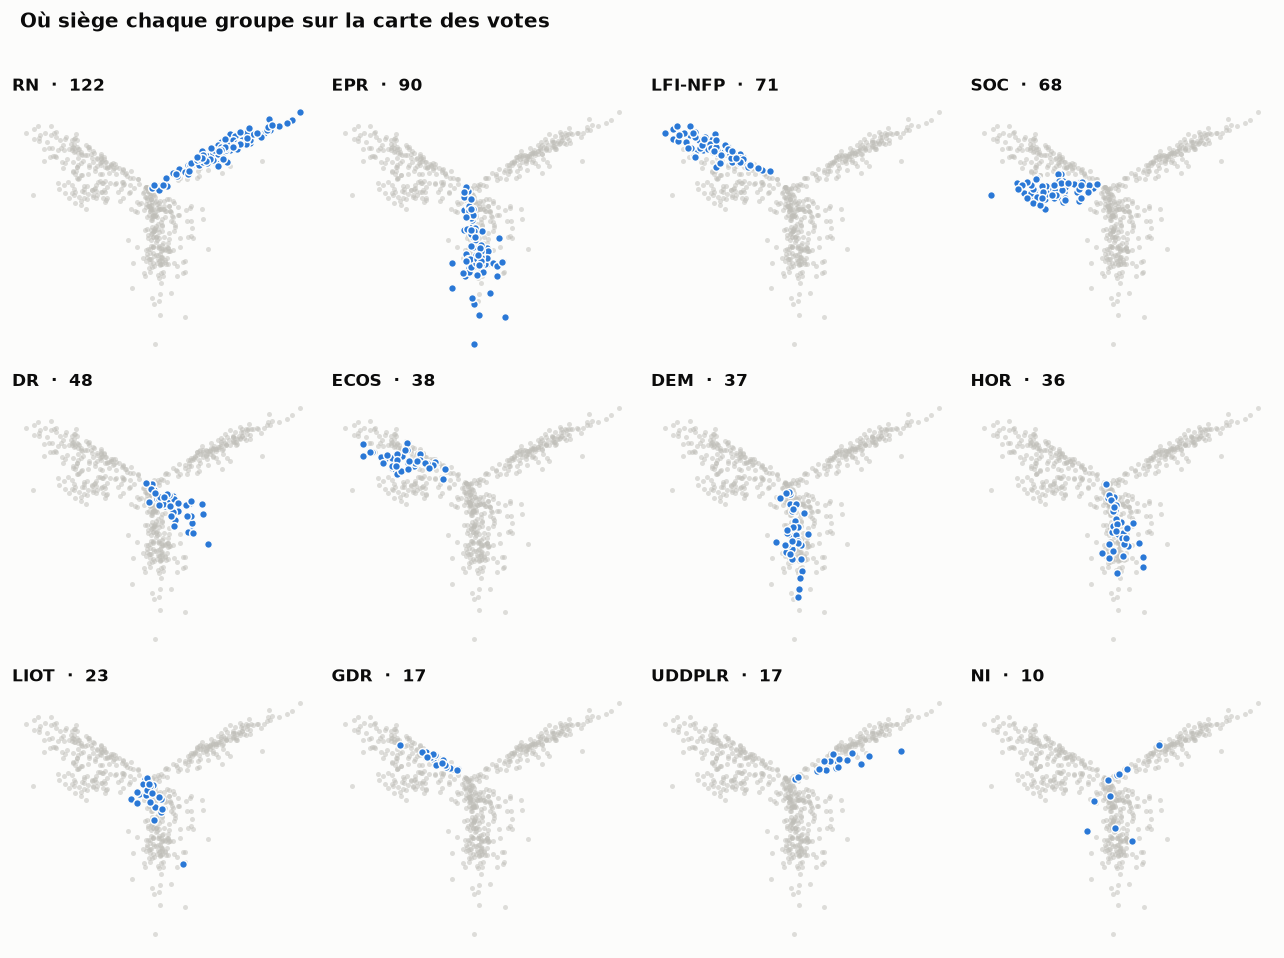

In [12]:
viz.carte_facettes(carte)
plt.show()

## 5. Discipline de groupe

La « ligne du groupe » est **recalculée** depuis le dépouillement nominatif.
L'Assemblée publie bien un champ `positionMajoritaire`, mais il diverge du vote
réellement majoritaire dans environ 8 % des cas — assez pour fabriquer des
dissidents qui n'existent pas.

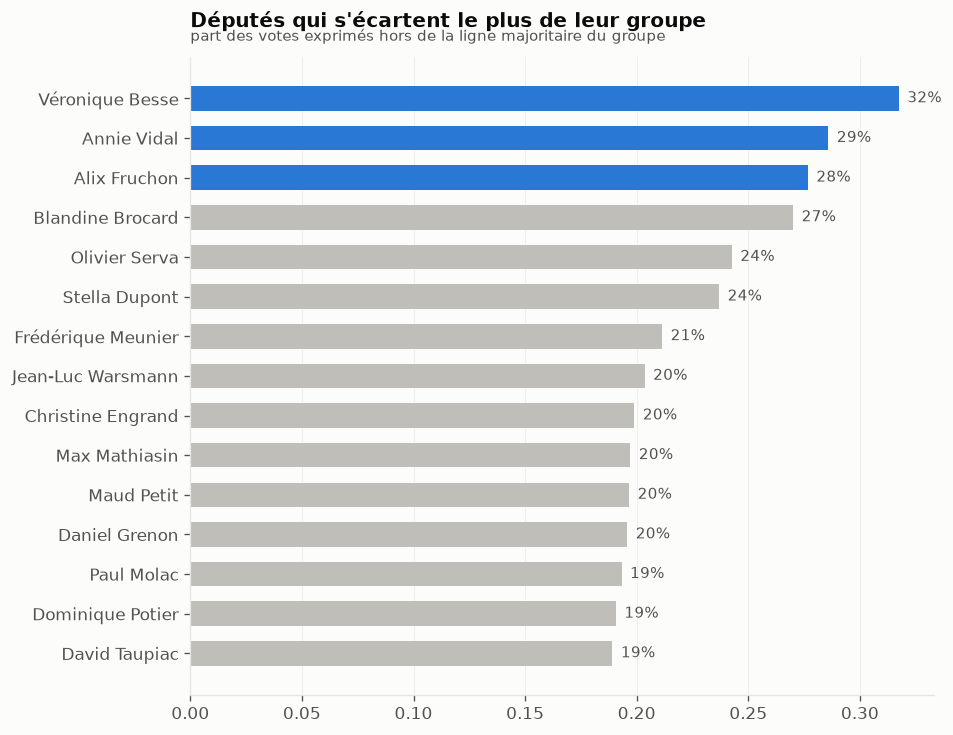

nom_complet,groupe,votes_exprimes,taux_dissidence
str,str,u32,f64
"""Véronique Besse""","""NI""",126,0.31746
"""Annie Vidal""","""EPR""",2347,0.285897
"""Alix Fruchon""","""DR""",683,0.27672
"""Blandine Brocard""","""DEM""",1181,0.27011
"""Olivier Serva""","""LIOT""",136,0.242647
"""Stella Dupont""","""NI""",211,0.236967
"""Frédérique Meunier""","""DR""",927,0.211435
"""Jean-Luc Warsmann""","""LIOT""",668,0.203593
"""Christine Engrand""","""NI""",196,0.19898


In [13]:
dissidents = analyze.dissidence(cube)
viz.barres_emphase(
    dissidents, "taux_dissidence", "nom_complet", k=15,
    titre="Députés qui s'écartent le plus de leur groupe",
    sous_titre="part des votes exprimés hors de la ligne majoritaire du groupe",
)
plt.show()
dissidents.head(10).select("nom_complet", "groupe", "votes_exprimes", "taux_dissidence")

In [14]:
# Les scrutins qui ont le plus fracturé les groupes
analyze.scrutins_clivants(cube, k=10).select("date", "taux_fracture", "titre")

date,taux_fracture,titre
str,f64,str
"""2024-12-02""",0.429577,"""l'amendement n° 57 de M. Ott à l'article premier de la propo…"
"""2024-12-02""",0.42069,"""l'amendement n° 61 de M. Fugit à l'article premier de la pro…"
"""2024-12-02""",0.395062,"""l'amendement n° 5 de Mme Batho et les amendements identiques…"
"""2024-12-02""",0.390071,"""l'amendement n° 69 de M. Chassaigne à l'article premier de l…"
"""2024-12-02""",0.373016,"""l'amendement n° 33 de Mme Marsaud et les amendements identiq…"
"""2024-12-02""",0.369697,"""l'amendement n° 4 de Mme Batho à l'article premier de la pro…"
"""2024-12-02""",0.358974,"""l'amendement n° 6 de Mme Batho à l'article premier de la pro…"
"""2024-12-02""",0.338776,"""l'amendement de suppression n° 1 de Mme Batho et l'amendemen…"
"""2024-12-02""",0.310078,"""l'amendement n° 45 de M. Taupiac et l'amendement identique s…"


In [15]:
# Et ceux qui se sont joués à quelques voix
analyze.scrutins_serres(cube, k=10, ecart_max=6)

date,numero,ecart,n_pour,n_contre,sort_code,titre
str,i64,i64,i64,i64,str,str
"""2024-10-25""",117,0,113,113,"""rejeté""","""l'amendement n° 3250 de Mme Simonnet à l'article 11 (examen …"
"""2024-10-26""",166,0,98,98,"""rejeté""","""l'amendement n° 1714 de M. Potier après l'article 13 du proj…"
"""2024-10-30""",203,0,57,57,"""rejeté""","""l'amendement n° 903 de M. Simion après l'article 6 du projet…"
"""2024-11-08""",352,0,68,68,"""rejeté""","""l'amendement n° 205 de M. Pauget après l'article 26 du proje…"
"""2024-11-08""",353,0,69,69,"""rejeté""","""l'amendement n° 2741 de M. Rodwell après l'article 26 du pro…"
"""2025-01-21""",556,0,91,91,"""rejeté""","""l'amendement n° 171 de Mme Youssouffa après l'article 16 du …"
"""2025-01-21""",558,0,95,95,"""rejeté""","""l'amendement n° 255 de M. Gosselin et l'amendement identique…"
"""2025-01-29""",665,0,47,47,"""rejeté""","""l'amendement n° 24 de M. Jolivet à l'article premier de la p…"
"""2025-02-11""",769,0,82,82,"""rejeté""","""l'amendement n° 200 de M. Boucard après l'article 7 de la pr…"


## 6. Participation

Le dénominateur compte autant que le numérateur : on rapporte les votes exprimés
aux seuls scrutins où le député siégeait, et on retire les non-votes structurels
(membre du Gouvernement, président de séance) qui ne sont pas des absences.

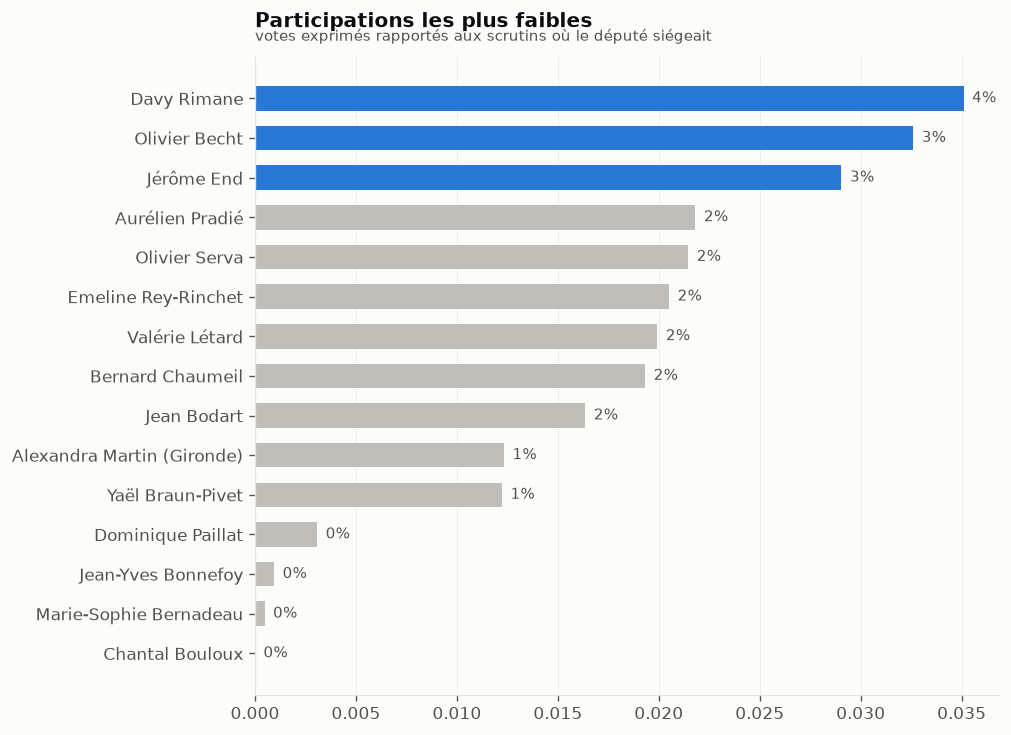

nom_complet,groupe,votes_exprimes,scrutins_eligibles,participation
str,str,i64,i64,f64
"""Marine Hamelet""","""RN""",6527,8434,0.773891
"""Claire Marais-Beuil""","""RN""",6342,8434,0.751956
"""Emeric Salmon""","""RN""",5961,8434,0.706782
"""Jacques Oberti""","""SOC""",5426,8434,0.643348
"""Anthony Brosse""","""EPR""",5373,8434,0.637064
"""Lisette Pollet""","""RN""",5285,8434,0.62663
"""David Magnier""","""RN""",5169,8434,0.612876
"""Christine Loir""","""RN""",5037,8434,0.597226
"""Edwige Diaz""","""RN""",5026,8434,0.595921


In [16]:
part = analyze.participation(cube)
viz.barres_emphase(
    part.tail(15).reverse(), "participation", "nom_complet", k=15,
    titre="Participations les plus faibles",
    sous_titre="votes exprimés rapportés aux scrutins où le député siégeait",
)
plt.show()
part.head(10).select("nom_complet", "groupe", "votes_exprimes", "scrutins_eligibles", "participation")

## 7. « Quels sujets explosent cette semaine ? »

On compte les termes des titres de scrutins et des exposés sommaires
d'amendements, semaine par semaine, puis on compare chaque terme à **sa propre
moyenne récente**. Un terme ne remonte pas parce qu'il est fréquent — « article »
et « gouvernement » le sont toujours — mais parce qu'il l'est plus que d'habitude.

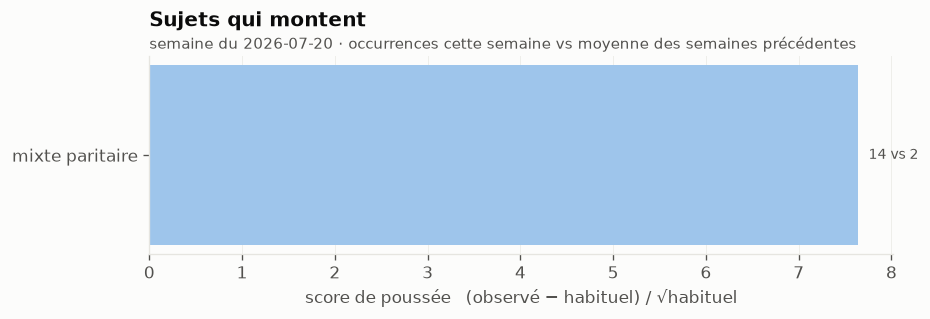

semaine,terme,n,moyenne_precedente,score
date,str,u32,f64,f64
2026-07-20,"""mixte paritaire""",14,1.625,7.638016


In [17]:
freqs = topics.frequences_hebdo("scrutins")     # "tout" inclut les amendements (plus lent)
montants = topics.sujets_qui_montent(freqs, k=15)
viz.barres_sujets(montants)
plt.show()
montants

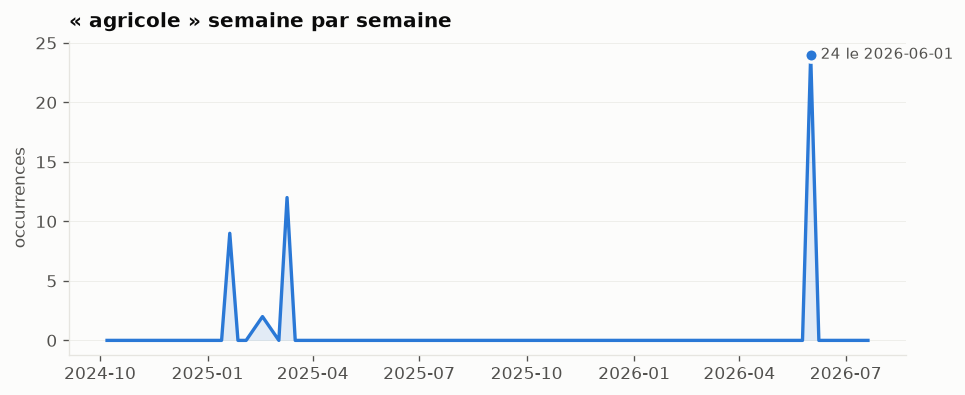

In [18]:
# Suivre un terme précis dans le temps
terme = "agricole"
viz.courbe_terme(topics.serie_terme(terme, freqs=freqs), terme)
plt.show()

## 8. « Qui dépose quels amendements ? »

In [19]:
analyze.amendements_par_groupe()

groupe,amendements,adoptes,deputes_deposants,taux_adoption
str,u32,u32,u32,f64
"""LFI-NFP""",21587,1788,73,0.082828
"""DR""",17573,2170,61,0.123485
"""ECOS""",15106,1557,38,0.103072
"""RN""",15058,760,125,0.050472
"""EPR""",13365,2975,110,0.222596
"""SOC""",13330,2440,69,0.183046
"""GDR""",6483,603,18,0.093012
"""LIOT""",5531,1074,26,0.194178
"""DEM""",4920,1002,40,0.203659


In [20]:
analyze.amendements_par_depute(15).drop("auteur_uid")

nom_complet,groupe,amendements,adoptes,rejetes,cosignataires_moyen,taux_adoption
str,str,u32,u32,u32,f64,f64
"""Bastien Lachaud""","""LFI-NFP""",2609,40,208,57.465696,0.015332
"""Thibault Bazin""","""DR""",2031,476,454,2.231905,0.234367
"""Matthias Renault""","""RN""",1275,27,507,38.771765,0.021176
"""Philippe Juvin""","""DR""",1250,250,444,3.3224,0.2
"""Lisa Belluco""","""ECOS""",1245,62,208,30.676305,0.049799
"""Sophie Taillé-Polian""","""ECOS""",1209,61,286,29.26799,0.050455
"""Emmanuel Grégoire""","""SOC""",1203,16,114,20.031588,0.0133
"""Gérault Verny""","""UDDPLR""",1131,5,146,0.98939,0.004421
"""Aurélien Taché""","""LFI-NFP""",1098,28,116,41.979964,0.025501


Le taux d'adoption se lit avec prudence : un amendement de la majorité et un
amendement d'opposition ne jouent pas le même jeu, et « Tombé » ou « Non
soutenu » ne veut pas dire « Rejeté ».

In [21]:
load("amendements")["sort"].value_counts().sort("count", descending=True)

sort,count
str,u32
null,54485
"""Rejeté""",29708
"""Adopté""",16174
"""Tombé""",11212
"""Non soutenu""",7435
"""Retiré""",4210


## 9. Les alertes de la semaine

C'est la sortie destinée à une newsletter, un fil social ou un tableau de bord :
uniquement ce qui s'écarte de la normale.

In [22]:
semaine = alerts.derniere_semaine()
print(f"Semaine du {semaine}\n")

for a in alerts.toutes_les_alertes(semaine, cube=cube):
    print(a, "\n")

Semaine du 2026-07-20



[fracture] GDR divisé : 10/17 votes hors ligne
    2026-07-21 — l'ensemble du projet de loi relatif à la protection des enfants (première lecture). 

[fracture] UDDPLR divisé : 9/17 votes hors ligne
    2026-07-21 — l'ensemble de la proposition de loi visant à protéger les mineurs des risques auxquels les expose l'utilisation des réseaux sociaux (texte de la commission mixte paritaire). 

[fracture] HOR divisé : 10/19 votes hors ligne
    2026-07-20 — l'amendement n° 7 du Gouvernement au projet de loi d'urgence pour la protection et la souveraineté agricoles (texte de la commission mixte paritaire). 

[fracture] LIOT divisé : 12/23 votes hors ligne
    2026-07-20 — l'ensemble du projet de loi d'urgence pour la protection et la souveraineté agricoles (texte de la commission mixte paritaire). 

[fracture] SOC divisé : 16/33 votes hors ligne
    2026-07-21 — le sous-amendement n° 2 de Mme Perrine Goulet à l'amendement n° 1 du Gouvernement de rétablissement de l'article 11 (supprimé) du pr

## 10. Et ensuite

Le bulletin Markdown complet, graphiques compris :

```bash
uv run radar rapport
```

**Attention à un piège que ce notebook ne corrige pas.** Tous les chiffres
ci-dessus agrègent les 8 434 scrutins sans distinction, alors que 86 % d'entre
eux portent sur un amendement. C'est le sujet du notebook `02`, et ça change
plusieurs conclusions — notamment sur la solidité de l'alliance de gauche.

Quelques pistes encore ouvertes :

- **Interventions en séance** — le compte rendu (dataset *Syceron*) permettrait
  d'ajouter le temps de parole aux classements.
- **Dossiers législatifs** — rattacher chaque scrutin à son dossier donnerait des
  séries par texte plutôt que par mot-clé.
- **Automatisation** — `radar update && radar rapport` en tâche planifiée
  hebdomadaire suffit à alimenter un site ou une newsletter.

Source : open data de l'Assemblée nationale, Licence Ouverte 2.0.